#### environment

In [1]:
import os 
import numpy as np
from numpy import full
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
from predict_loop_functions import predict_loop, noise_iterations, filter_region, spike_plot, line_plot_mean, five_turning_curves
from scipy.stats import linregress

In [2]:
# use image stack from july16 already saved
image_stack = np.load('saved_inputs_outputs//image_stack_july16.npy')

In [3]:
neurons = np.array([1685,368,1571,670,1918,1231,6795,6492,2507,1444,2361,6699,6672,6790,6209,6699,
           1447,5583,2237,2161,7217,5114,4321,4823,6822,5935,823,6501,6819,5782])

#### predictions

In [ ]:
d3_sum, d3_mean, d3_var, d3_labels = predict_loop('dynamic', image_stack, 3, [[4,7]])

In [ ]:
d15_sum, d15_mean, d15_var, d15_labels = predict_loop('dynamic', image_stack, 15, [[4,7]])

In [6]:
d30_sum, d30_mean, d30_var, d30_labels = predict_loop('dynamic', image_stack, 30, [[4,7]])

In [7]:
c3_sum, c3_mean, c3_var, c3_labels = predict_loop('constant', image_stack, 3, [[4,7]])

In [8]:
c15_sum, c15_mean, c15_var, c15_labels = predict_loop('constant', image_stack, 15, [[4,7]])

In [9]:
c30_sum, c30_mean, c30_var, c30_labels = predict_loop('constant', image_stack, 30, [[4,7]])

In [10]:
dbin_sum, dbin_mean, dbin_var, dbin_labels = predict_loop('dynamic', image_stack, 0, [[4,7]], stochastic_bin_param = True)

In [11]:
cbin_sum, cbin_mean, cbin_var, cbin_labels = predict_loop('constant', image_stack, 0, [[4,7]], stochastic_bin_param = True)

In [34]:
# save predictions to predictions_july21
for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin']:
    for type_output in ['_sum', '_mean', '_var', '_labels']:
        file_name = noise + type_output
        path = 'saved_inputs_outputs//predictions_july21//' + file_name
        np.save(path, arr = globals()[file_name])

##### add no noise prediction for turning curves

In [ ]:
no_noise_sum, no_noise_mean, no_noise_var, no_noise_labels = predict_loop('no noise', image_stack, 0, [[4,7]])

In [14]:
for type in ['_sum', '_mean', '_var', '_labels']:
        file_name = 'no_noise' + type
        path = 'saved_inputs_outputs//predictions_july21//' + file_name
        np.save(path, arr = globals()[file_name])

#### load predictions

In [4]:
for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin', 'no_noise']:
    for type in ['_sum', '_mean', '_var', '_labels']:
        file_name = noise + type + '.npy'
        var_name = noise + type
        path = 'saved_inputs_outputs//predictions_july21//' + file_name
        globals()[var_name] = np.load(path)

In [5]:
# load predictions by region
for region in np.unique(d3_labels):
    for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin', 'no_noise']:
        for type in ['_sum', '_mean', '_var']:
            file_name = noise + type + '_r' + str(region) +  '.npy'
            path = 'saved_inputs_outputs//predictions_july21//' + file_name
            array_name = noise + type + '_r' + str(region)
            globals()[array_name] = np.load(path)

#### filtering by region (function completed)

In [5]:
for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin', 'no_noise']:
    for type_output in ['_sum', '_mean', '_var']:
        for i in np.unique(d3_labels): # use first prediction array to get possible regions 
            print(f'noise {noise}, type output {type_output}, label {i}')
            filtered_array = filter_region(i, globals()[noise+'_labels'], globals()[noise+type_output])
            file_name = noise+type_output+'_r'+str(i)
            #globals()[filtered_array] = 
            path = 'saved_inputs_outputs//predictions_july21//' + file_name
            np.save(path, arr = filtered_array)

noise c3, type output _sum, label 1
noise c3, type output _sum, label 2
noise c3, type output _sum, label 3
noise c3, type output _sum, label 4
noise c3, type output _mean, label 1
noise c3, type output _mean, label 2
noise c3, type output _mean, label 3
noise c3, type output _mean, label 4
noise c3, type output _var, label 1
noise c3, type output _var, label 2
noise c3, type output _var, label 3
noise c3, type output _var, label 4
noise c15, type output _sum, label 1
noise c15, type output _sum, label 2
noise c15, type output _sum, label 3
noise c15, type output _sum, label 4
noise c15, type output _mean, label 1
noise c15, type output _mean, label 2
noise c15, type output _mean, label 3
noise c15, type output _mean, label 4
noise c15, type output _var, label 1
noise c15, type output _var, label 2
noise c15, type output _var, label 3
noise c15, type output _var, label 4
noise c30, type output _sum, label 1
noise c30, type output _sum, label 2
noise c30, type output _sum, label 3
noise

#### filter function fix

In [15]:
test1, test2, test3, test_labels = predict_loop('no noise', image_stack, 0, [[4,7]], noise_seeds = 3, num_frames = 2)

In [16]:
type(test_labels[0])

pandas.core.series.Series

In [17]:
test_labels_flat = np.array(test_labels[0]).flatten()

In [6]:
type(test_labels_flat)

numpy.ndarray

In [7]:
for x in test_labels_flat: 
    if not (type(x) != int): print(x)

In [18]:
test1_r2 = filter_region(2, test_labels_flat, test1)

In [19]:
test1_r2.shape

(5, 3, 983)

In [20]:
pd.DataFrame(test_labels).T.value_counts()

brain_area
1             5312
2              983
4              811
3              387
Name: count, dtype: int64

#### LINE PLOTTING DATA

In [6]:
print('Value Counts for Scan Labels, c3_mean')
print(pd.DataFrame(c3_labels).T.value_counts())

Value Counts for Scan Labels, c3_mean
0
1    5312
2     983
4     811
3     387
Name: count, dtype: int64


Region 1

In [6]:
# region 1 dynamic, plotting data
plot_mean_d30_r1 = line_plot_mean(d30_mean_r1, [i for i in range(100)])
plot_mean_d15_r1 = line_plot_mean(d15_mean_r1, [i for i in range(100)])
plot_mean_d3_r1 = line_plot_mean(d3_mean_r1, [i for i in range(100)])
plot_mean_dbin_r1 = line_plot_mean(dbin_mean_r1, [i for i in range(100)])

In [7]:
# region 1 constant, plotting data
plot_mean_c30_r1 = line_plot_mean(c30_mean_r1, [i for i in range(100)])
plot_mean_c15_r1 = line_plot_mean(c15_mean_r1, [i for i in range(100)])
plot_mean_c3_r1 = line_plot_mean(c3_mean_r1, [i for i in range(100)])
plot_mean_cbin_r1 = line_plot_mean(cbin_mean_r1, [i for i in range(100)])

Region 2

In [8]:
# region 2 dynamic, plotting data
plot_mean_d30_r2 = line_plot_mean(d30_mean_r2, [i for i in range(100)])
plot_mean_d15_r2 = line_plot_mean(d15_mean_r2, [i for i in range(100)])
plot_mean_d3_r2 = line_plot_mean(d3_mean_r2, [i for i in range(100)])
plot_mean_dbin_r2 = line_plot_mean(dbin_mean_r2, [i for i in range(100)])

In [9]:
# region 2 constant, plotting data
plot_mean_c30_r2 = line_plot_mean(c30_mean_r2, [i for i in range(100)])
plot_mean_c15_r2 = line_plot_mean(c15_mean_r2, [i for i in range(100)])
plot_mean_c3_r2 = line_plot_mean(c3_mean_r2, [i for i in range(100)])
plot_mean_cbin_r2 = line_plot_mean(cbin_mean_r2, [i for i in range(100)])

Region 3

In [10]:
# region 3 dynamic, plotting data
plot_mean_d30_r3 = line_plot_mean(d30_mean_r3, [i for i in range(100)])
plot_mean_d15_r3 = line_plot_mean(d15_mean_r3, [i for i in range(100)])
plot_mean_d3_r3 = line_plot_mean(d3_mean_r3, [i for i in range(100)])
plot_mean_dbin_r3 = line_plot_mean(dbin_mean_r3, [i for i in range(100)])

In [11]:
# region 3 constant, plotting data
plot_mean_c30_r3 = line_plot_mean(c30_mean_r3, [i for i in range(100)])
plot_mean_c15_r3 = line_plot_mean(c15_mean_r3, [i for i in range(100)])
plot_mean_c3_r3 = line_plot_mean(c3_mean_r3, [i for i in range(100)])
plot_mean_cbin_r3 = line_plot_mean(cbin_mean_r3, [i for i in range(100)])

Region 4

In [12]:
# region 4 dynamic, plotting data
plot_mean_d30_r4 = line_plot_mean(d30_mean_r4, [i for i in range(100)])
plot_mean_d15_r4 = line_plot_mean(d15_mean_r4, [i for i in range(100)])
plot_mean_d3_r4 = line_plot_mean(d3_mean_r4, [i for i in range(100)])
plot_mean_dbin_r4 = line_plot_mean(dbin_mean_r4, [i for i in range(100)])

In [13]:
# region 4 constant, plotting data
plot_mean_c30_r4 = line_plot_mean(c30_mean_r4, [i for i in range(100)])
plot_mean_c15_r4 = line_plot_mean(c15_mean_r4, [i for i in range(100)])
plot_mean_c3_r4 = line_plot_mean(c3_mean_r4, [i for i in range(100)])
plot_mean_cbin_r4 = line_plot_mean(cbin_mean_r4, [i for i in range(100)])

#### note: get filtered regions and line plot data from above cells

#### non-normalized

region 1

In [27]:
dynamic_arrays_r1 = [plot_mean_d3_r1, plot_mean_d15_r1, plot_mean_d30_r1, plot_mean_dbin_r1]
constant_arrays_r1 = [plot_mean_c3_r1, plot_mean_c15_r1, plot_mean_c30_r1, plot_mean_cbin_r1]

c:\Users\joshf\OneDrive\GitHub\fnn-haefner\fnn\input_noise\predict_loop_functions.py:487: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
c:\Users\joshf\OneDrive\GitHub\fnn-haefner\fnn\input_noise\predict_loop_functions.py:490: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


Dynamic Noise 95% Confidence Interval for Slope: [-0.001, 0.007]
Constant Noise 95% Confidence Interval for Slope: [-0.001, 0.009]


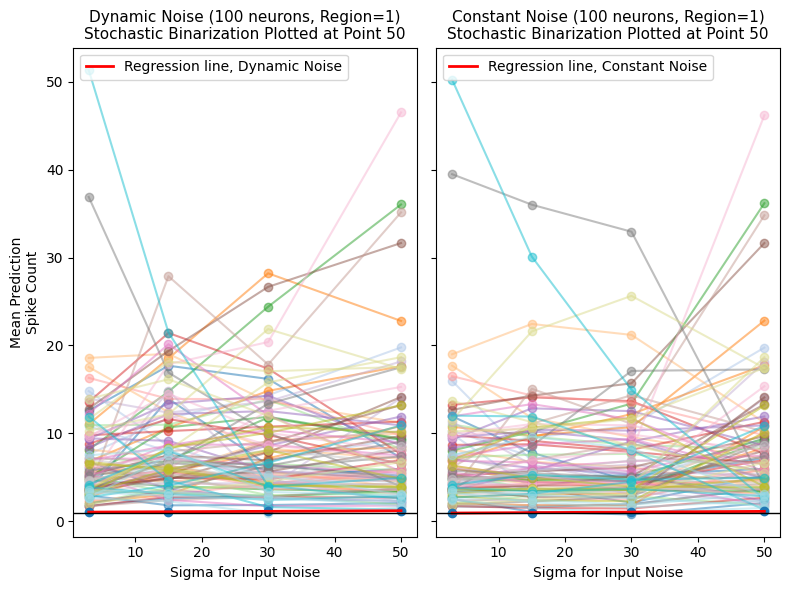

In [28]:
spike_plot(dynamic_arrays_r1, constant_arrays_r1, True, False, 1)

region 2

In [29]:
dynamic_arrays_r2 = [plot_mean_d3_r2, plot_mean_d15_r2, plot_mean_d30_r2, plot_mean_dbin_r2]
constant_arrays_r2 = [plot_mean_c3_r2, plot_mean_c15_r2, plot_mean_c30_r2, plot_mean_cbin_r2]

Dynamic Noise 95% Confidence Interval for Slope: [-0.011, 0.016]
Constant Noise 95% Confidence Interval for Slope: [-0.002, 0.014]


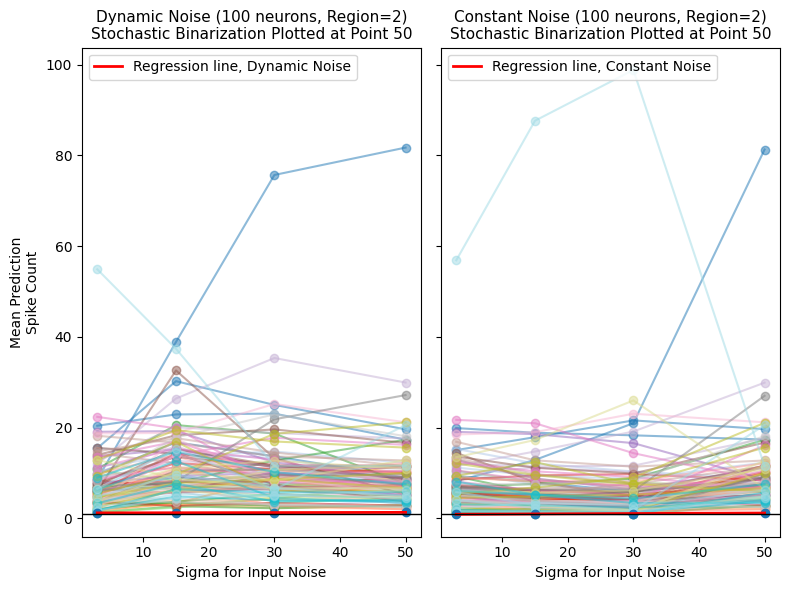

In [30]:
spike_plot(dynamic_arrays_r2, constant_arrays_r2, True, False, 2)

region 3

In [31]:
dynamic_arrays_r3 = [plot_mean_d3_r3, plot_mean_d15_r3, plot_mean_d30_r3, plot_mean_dbin_r3]
constant_arrays_r3 = [plot_mean_c3_r3, plot_mean_c15_r3, plot_mean_c30_r3, plot_mean_cbin_r3]

Dynamic Noise 95% Confidence Interval for Slope: [-0.001, 0.007]
Constant Noise 95% Confidence Interval for Slope: [-0.001, 0.009]


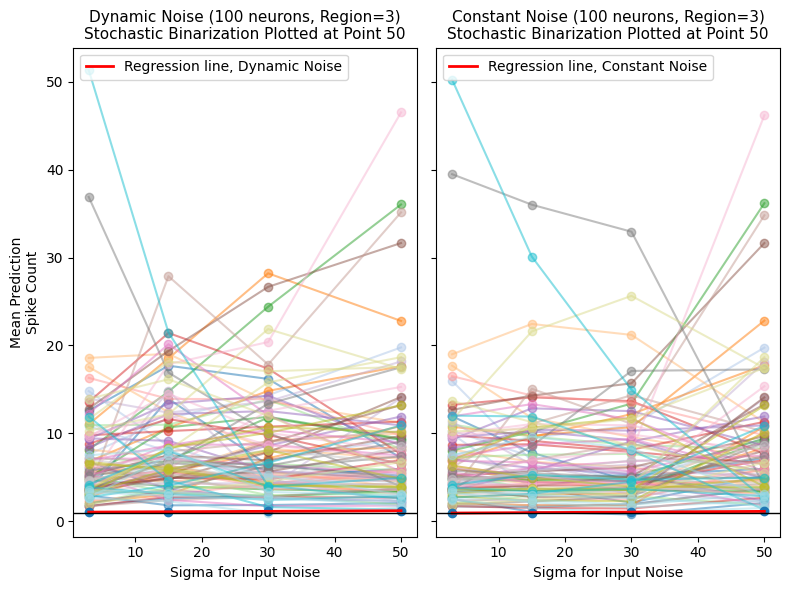

In [32]:
spike_plot(dynamic_arrays_r1, constant_arrays_r1, True, False, 3)

region 4

In [33]:
dynamic_arrays_r4 = [plot_mean_d3_r4, plot_mean_d15_r4, plot_mean_d30_r4, plot_mean_dbin_r4]
constant_arrays_r4 = [plot_mean_c3_r4, plot_mean_c15_r4, plot_mean_c30_r4, plot_mean_cbin_r4]

Dynamic Noise 95% Confidence Interval for Slope: [-0.001, 0.007]
Constant Noise 95% Confidence Interval for Slope: [-0.001, 0.009]


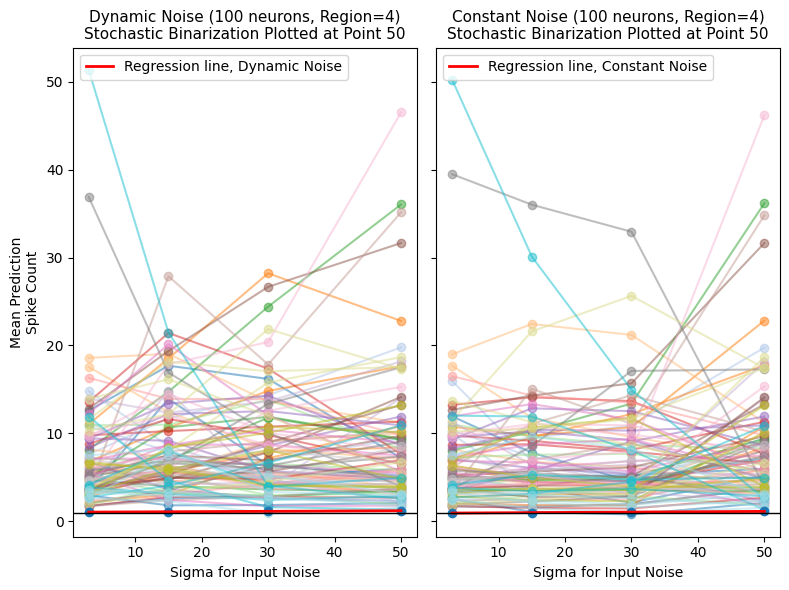

In [34]:
spike_plot(dynamic_arrays_r1, constant_arrays_r1, True, False, 4)

#### spike_plot()

In [14]:
dynamic_means = [plot_mean_d3_r1, plot_mean_d15_r1, plot_mean_d30_r1] 
constant_means = [plot_mean_c3_r1, plot_mean_c15_r1, plot_mean_c30_r1]

shape of dynamic_mean_plot (3,)
shapes: sigmas(list) 3, constant_mean_plot (3,)
Dynamic Noise 95% Confidence Interval for Slope: [-0.001, 0.026]
Constant Noise 95% Confidence Interval for Slope: [-0.001, 0.033]


c:\Users\joshf\OneDrive\GitHub\fnn-haefner\fnn\input_noise\predict_loop_functions.py:495: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
c:\Users\joshf\OneDrive\GitHub\fnn-haefner\fnn\input_noise\predict_loop_functions.py:497: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


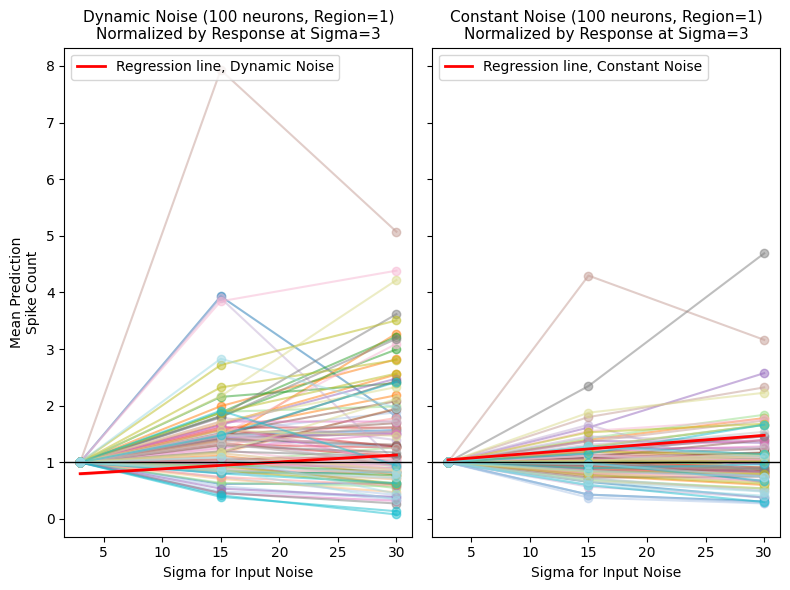

In [15]:
spike_plot(dynamic_means, constant_means,True, True, 1)

C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:56: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


Dynamic Noise 95% Confidence Interval for Slope: [-0.001, 0.007]
Constant Noise 95% Confidence Interval for Slope: [-0.001, 0.009


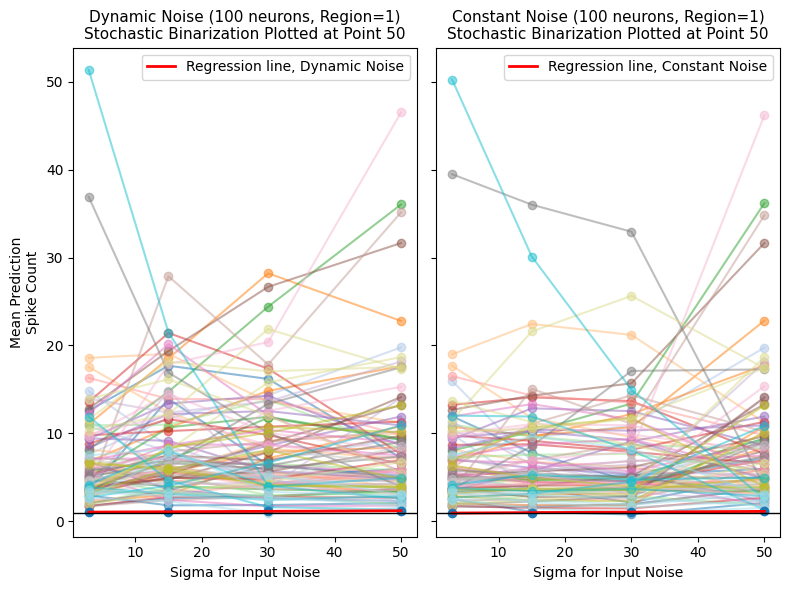

In [38]:
spike_plot(dynamic_means, constant_means, False, 1)

#### sigma versus variance

#### formatting var data for plot

region 1

In [14]:
d3_var_r1 = filter_region(1, 5, d3_labels, d3_var)
d15_var_r1 = filter_region(1, 5, d3_labels, d15_var)
d30_var_r1 = filter_region(1, 5, d3_labels, d30_var)
dbin_var_r1 = filter_region(1, 5, d3_labels, dbin_var)


In [15]:
plot_var_d30_r1 = line_plot_mean(d30_var_r1, [i for i in range(100)])
plot_var_d15_r1 = line_plot_mean(d15_var_r1, [i for i in range(100)])
plot_var_d3_r1 = line_plot_mean(d3_var_r1, [i for i in range(100)])
plot_var_dbin_r1 = line_plot_mean(dbin_var_r1, [i for i in range(100)])

In [16]:
c3_var_r1 = filter_region(1, 5, c3_labels, c3_var)
c15_var_r1 = filter_region(1, 5, c3_labels, c15_var)
c30_var_r1 = filter_region(1, 5, c3_labels, c30_var)
cbin_var_r1 = filter_region(1, 5, c3_labels, cbin_var)


In [17]:
plot_var_c30_r1 = line_plot_mean(c30_var_r1, [i for i in range(100)])
plot_var_c15_r1 = line_plot_mean(c15_var_r1, [i for i in range(100)])
plot_var_c3_r1 = line_plot_mean(c3_var_r1, [i for i in range(100)])
plot_var_cbin_r1 = line_plot_mean(cbin_var_r1, [i for i in range(100)])

region 2

In [43]:
d3_var_r2 = filter_region(2, 5, d3_labels, d3_var)
d15_var_r2 = filter_region(2, 5, d3_labels, d15_var)
d30_var_r2 = filter_region(2, 5, d3_labels, d30_var)
dbin_var_r2 = filter_region(2, 5, d3_labels, dbin_var)


In [44]:
plot_var_d30_r2 = line_plot_mean(d30_var_r2, [i for i in range(100)])
plot_var_d15_r2 = line_plot_mean(d15_var_r2, [i for i in range(100)])
plot_var_d3_r2 = line_plot_mean(d3_var_r2, [i for i in range(100)])
plot_var_dbin_r2 = line_plot_mean(dbin_var_r2, [i for i in range(100)])

In [45]:
c3_var_r2 = filter_region(2, 5, c3_labels, c3_var)
c15_var_r2 = filter_region(2, 5, c3_labels, c15_var)
c30_var_r2 = filter_region(2, 5, c3_labels, c30_var)
cbin_var_r2 = filter_region(2, 5, c3_labels, cbin_var)


In [46]:
plot_var_c30_r2 = line_plot_mean(c30_var_r2, [i for i in range(100)])
plot_var_c15_r2 = line_plot_mean(c15_var_r2, [i for i in range(100)])
plot_var_c3_r2 = line_plot_mean(c3_var_r2, [i for i in range(100)])
plot_var_cbin_r2 = line_plot_mean(cbin_var_r2, [i for i in range(100)])

region 3

In [47]:
d3_var_r3 = filter_region(3, 5, d3_labels, d3_var)
d15_var_r3 = filter_region(3, 5, d3_labels, d15_var)
d30_var_r3 = filter_region(3, 5, d3_labels, d30_var)
dbin_var_r3 = filter_region(3, 5, d3_labels, dbin_var)


In [48]:
plot_var_d30_r3 = line_plot_mean(d30_var_r3, [i for i in range(100)])
plot_var_d15_r3 = line_plot_mean(d15_var_r3, [i for i in range(100)])
plot_var_d3_r3 = line_plot_mean(d3_var_r3, [i for i in range(100)])
plot_var_dbin_r3 = line_plot_mean(dbin_var_r3, [i for i in range(100)])

In [49]:
c3_var_r3 = filter_region(3, 5, c3_labels, c3_var)
c15_var_r3 = filter_region(3, 5, c3_labels, c15_var)
c30_var_r3 = filter_region(3, 5, c3_labels, c30_var)
cbin_var_r3 = filter_region(3, 5, c3_labels, cbin_var)

In [50]:
plot_var_c30_r3 = line_plot_mean(c30_var_r3, [i for i in range(100)])
plot_var_c15_r3 = line_plot_mean(c15_var_r3, [i for i in range(100)])
plot_var_c3_r3 = line_plot_mean(c3_var_r3, [i for i in range(100)])
plot_var_cbin_r3 = line_plot_mean(cbin_var_r3, [i for i in range(100)])

region 4

In [51]:
d3_var_r4 = filter_region(4, 5, d3_labels, d3_var)
d15_var_r4 = filter_region(4, 5, d3_labels, d15_var)
d30_var_r4 = filter_region(4, 5, d3_labels, d30_var)
dbin_var_r4 = filter_region(4, 5, d3_labels, dbin_var)


In [52]:
plot_var_d30_r4 = line_plot_mean(d30_var_r4, [i for i in range(100)])
plot_var_d15_r4 = line_plot_mean(d15_var_r4, [i for i in range(100)])
plot_var_d3_r4 = line_plot_mean(d3_var_r4, [i for i in range(100)])
plot_var_dbin_r4 = line_plot_mean(dbin_var_r4, [i for i in range(100)])

In [53]:
c3_var_r4 = filter_region(4, 5, c3_labels, c3_var)
c15_var_r4 = filter_region(4, 5, c3_labels, c15_var)
c30_var_r4 = filter_region(4, 5, c3_labels, c30_var)
cbin_var_r4 = filter_region(4, 5, c3_labels, cbin_var)

In [54]:
plot_var_c30_r4 = line_plot_mean(c30_var_r4, [i for i in range(100)])
plot_var_c15_r4 = line_plot_mean(c15_var_r4, [i for i in range(100)])
plot_var_c3_r4 = line_plot_mean(c3_var_r4, [i for i in range(100)])
plot_var_cbin_r4 = line_plot_mean(cbin_var_r4, [i for i in range(100)])

#### non-normalized

region 1

In [55]:
dynamic_arrays_r1_var = [plot_var_d3_r1, plot_var_d15_r1, plot_var_d30_r1, plot_var_dbin_r1]
constant_arrays_r1_var = [plot_var_c3_r1, plot_var_c15_r1, plot_var_c30_r1, plot_var_cbin_r1]

C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:56: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


Dynamic Noise 95% Confidence Interval for Slope: [-1.007, 4.014]
Constant Noise 95% Confidence Interval for Slope: [0.255, 1.007


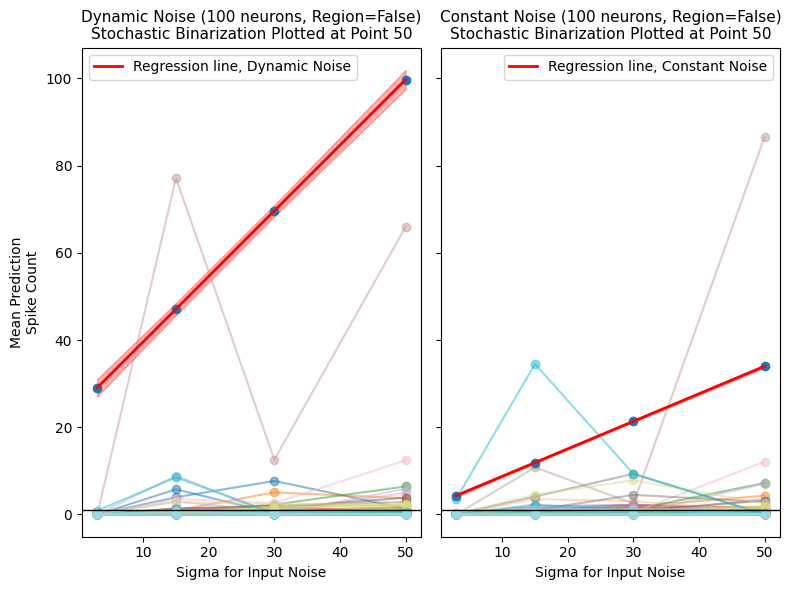

In [56]:
spike_plot(dynamic_arrays_r1_var, constant_arrays_r1_var, False, False, 1)

region 2

In [57]:
dynamic_arrays_r2_var = [plot_var_d3_r2, plot_var_d15_r2, plot_var_d30_r2, plot_var_dbin_r2]
constant_arrays_r2_var = [plot_var_c3_r2, plot_var_c15_r2, plot_var_c30_r2, plot_var_cbin_r2]

C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:56: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


Dynamic Noise 95% Confidence Interval for Slope: [-1.936, 4.689]
Constant Noise 95% Confidence Interval for Slope: [-1.546, 3.482


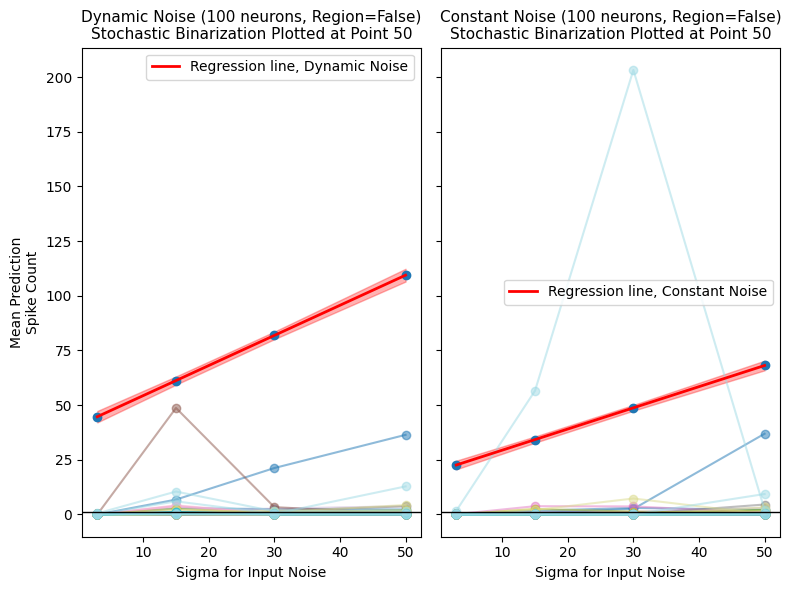

In [58]:
spike_plot(dynamic_arrays_r2_var, constant_arrays_r2_var, False, False, 2)

region 3

In [59]:
dynamic_arrays_r3_var = [plot_var_d3_r3, plot_var_d15_r3, plot_var_d30_r3, plot_var_dbin_r3]
constant_arrays_r3_var = [plot_var_c3_r3, plot_var_c15_r3, plot_var_c30_r3, plot_var_cbin_r3]

C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:56: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


Dynamic Noise 95% Confidence Interval for Slope: [1.148, 3.847]
Constant Noise 95% Confidence Interval for Slope: [0.558, 2.250


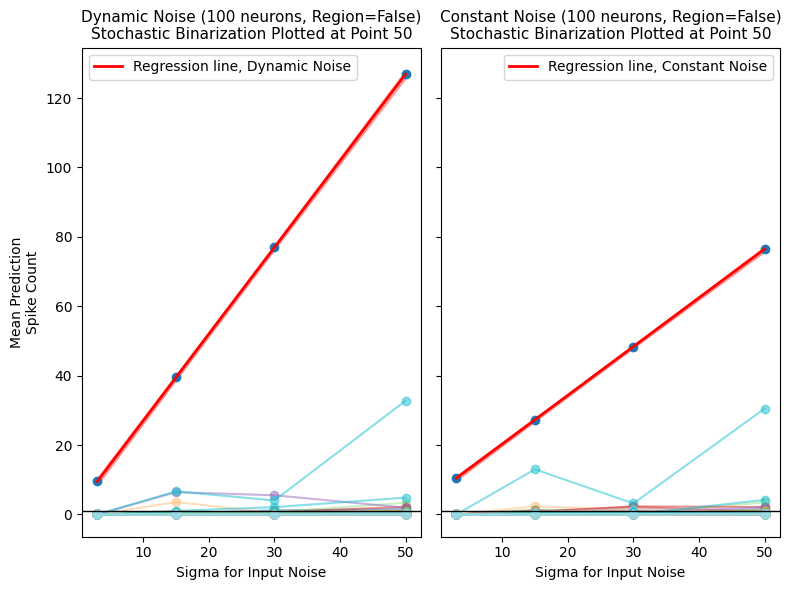

In [60]:
spike_plot(dynamic_arrays_r3_var, constant_arrays_r3_var, False, False, 3)

region 4

In [61]:
dynamic_arrays_r4_var = [plot_var_d3_r4, plot_var_d15_r4, plot_var_d30_r4, plot_var_dbin_r4]
constant_arrays_r4_var = [plot_var_c3_r4, plot_var_c15_r4, plot_var_c30_r4, plot_var_cbin_r4]

C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:56: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


Dynamic Noise 95% Confidence Interval for Slope: [-0.023, 1.084]
Constant Noise 95% Confidence Interval for Slope: [0.307, 0.795


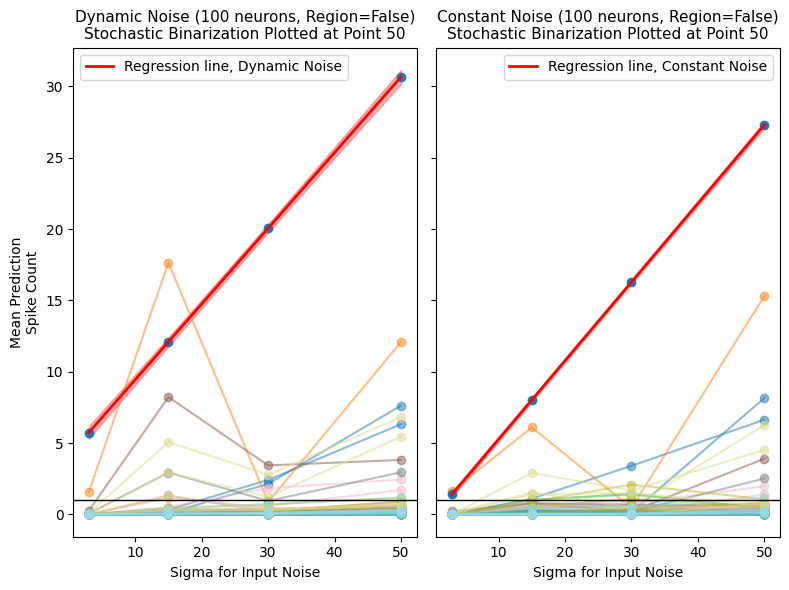

In [62]:
spike_plot(dynamic_arrays_r4_var, constant_arrays_r4_var, False, False, 4)

#### normalized

region 1

In [63]:
dynamic_arrays_r1_var = [plot_var_d3_r1, plot_var_d15_r1, plot_var_d30_r1, plot_var_dbin_r1]
constant_arrays_r1_var = [plot_var_c3_r1, plot_var_c15_r1, plot_var_c30_r1, plot_var_cbin_r1]

C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:56: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


Dynamic Noise 95% Confidence Interval for Slope: [-1.007, 4.014]
Constant Noise 95% Confidence Interval for Slope: [0.255, 1.007


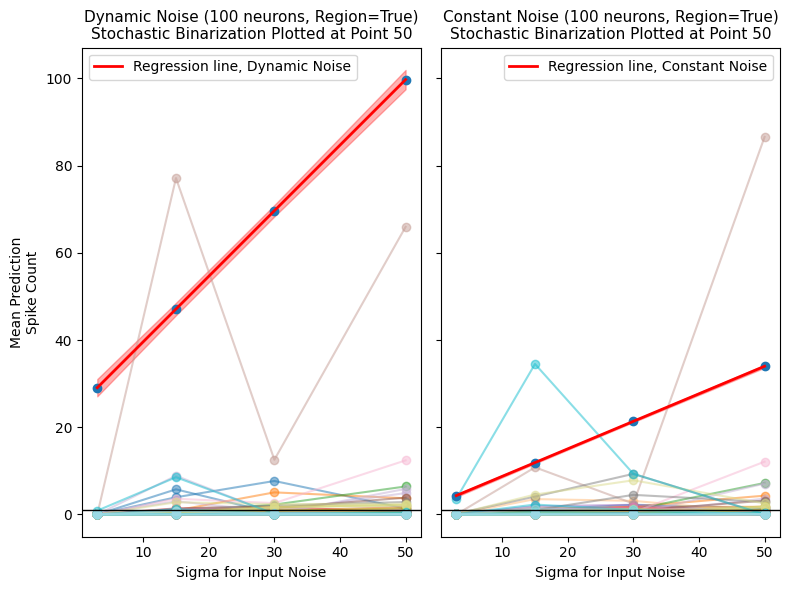

In [64]:
spike_plot(dynamic_arrays_r1_var, constant_arrays_r1_var, False, True, 1)

region 2

In [65]:
dynamic_arrays_r2_var = [plot_var_d3_r2, plot_var_d15_r2, plot_var_d30_r2, plot_var_dbin_r2]
constant_arrays_r2_var = [plot_var_c3_r2, plot_var_c15_r2, plot_var_c30_r2, plot_var_cbin_r2]

C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:56: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


Dynamic Noise 95% Confidence Interval for Slope: [-1.936, 4.689]
Constant Noise 95% Confidence Interval for Slope: [-1.546, 3.482


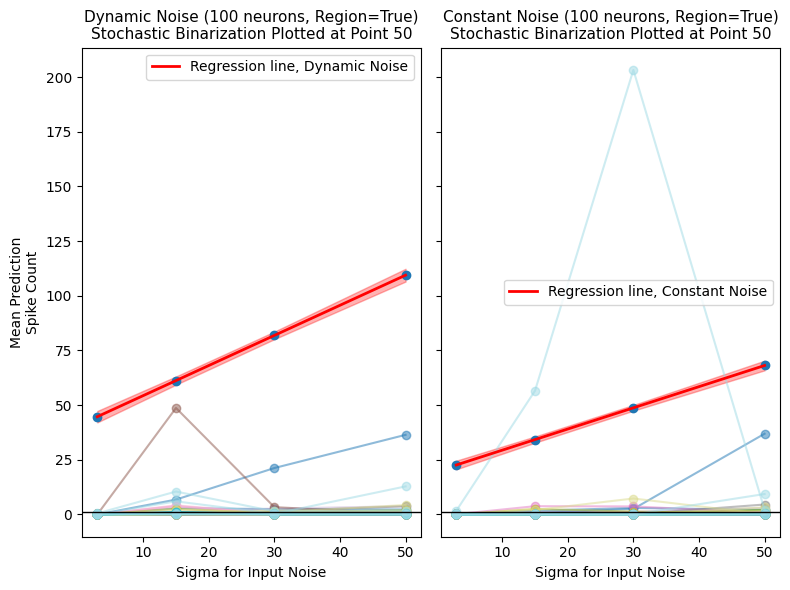

In [66]:
spike_plot(dynamic_arrays_r2_var, constant_arrays_r2_var, False, True, 2)

region 3

In [67]:
dynamic_arrays_r3_var = [plot_var_d3_r3, plot_var_d15_r3, plot_var_d30_r3, plot_var_dbin_r3]
constant_arrays_r3_var = [plot_var_c3_r3, plot_var_c15_r3, plot_var_c30_r3, plot_var_cbin_r3]

C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:56: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


Dynamic Noise 95% Confidence Interval for Slope: [1.148, 3.847]
Constant Noise 95% Confidence Interval for Slope: [0.558, 2.250


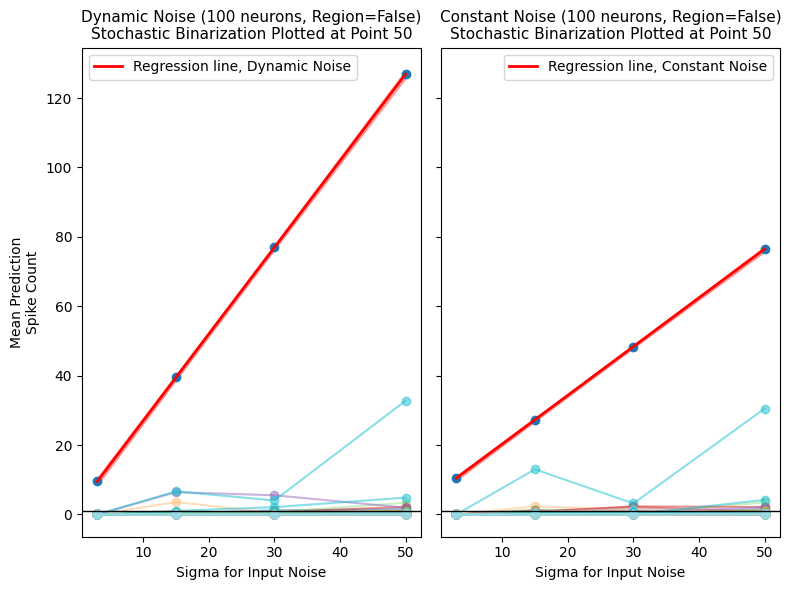

In [68]:
spike_plot(dynamic_arrays_r3_var, constant_arrays_r3_var, False, False, 3)

region 4

In [69]:
dynamic_arrays_r4_var = [plot_var_d3_r4, plot_var_d15_r4, plot_var_d30_r4, plot_var_dbin_r4]
constant_arrays_r4_var = [plot_var_c3_r4, plot_var_c15_r4, plot_var_c30_r4, plot_var_cbin_r4]

C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:56: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


Dynamic Noise 95% Confidence Interval for Slope: [-0.023, 1.084]
Constant Noise 95% Confidence Interval for Slope: [0.307, 0.795


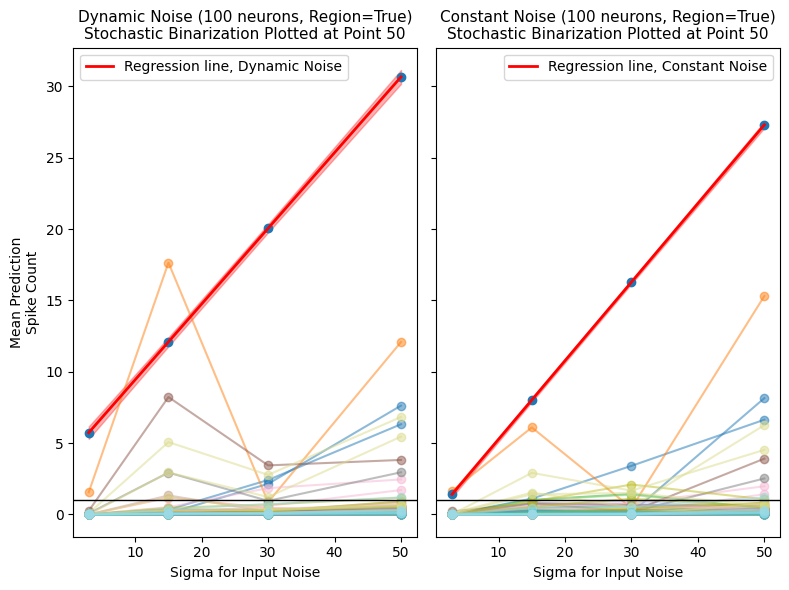

In [70]:
spike_plot(dynamic_arrays_r4_var, constant_arrays_r4_var, False, True, 4)

#### filtering out sum data

In [76]:
def filter_region(region_input: int, num_images: int, label_mapping, array):
    """
    Parameters
    ----------
    region_input: int
        specified region to output
    num_images: int
        number of images used for predict_loop()
    label_mapping: label
        mapping output from scans()
    array: np.array
        array to filter

    Returns
    -------
    array
        filtered array where brain region is equal to region_input
    """
    if (array.ndim == 3): label_mapping = np.repeat(label_mapping[:, np.newaxis, :], array.shape[1], axis = 1)
    concat_array = np.concatenate((array, label_mapping), axis=0)
    region_indices = np.where(concat_array[num_images] == region_input)
    return array[..., region_indices[0]]

In [87]:
d3_sum.shape

(5, 100, 7493)

In [88]:
d3_labels.shape

(1, 7493)

In [89]:
d3_labels_test = np.repeat(d3_labels[:, np.newaxis, :], d3_sum.shape[1], axis = 1)

In [90]:
d3_labels_test.shape

(1, 100, 7493)

In [91]:
concat = np.concatenate([d3_sum, d3_labels_test], axis = 0)

In [92]:
concat.shape

(6, 100, 7493)

In [93]:
test_filter = np.where(concat[5] == 4)[0]

In [94]:
test_filter.shape

(81100,)

In [86]:
d3_sum[..., test_filter].shape

(5, 100, 81100)

NOTE: issue is with concatenating here, adds too many new neuron instances

dynamic data

In [ ]:
d3_sum_r1 = filter_region(1, 5, d3_labels, d3_sum)
d15_sum_r1 = filter_region(1, 5, d15_labels, d15_sum)
d30_sum_r1 = filter_region(1, 5, d30_labels, d30_sum)
dbin_sum_r1 = filter_region(1, 5, dbin_labels, dbin_sum)

MemoryError: Unable to allocate 1.98 GiB for an array with shape (531200, 5, 100) and data type float64

In [62]:
d3_sum_r2 = filter_region(2, 5, d3_labels, d3_sum)
d15_sum_r2 = filter_region(2, 5, d15_labels, d15_sum)
d30_sum_r2 = filter_region(2, 5, d30_labels, d30_sum)
dbin_sum_r2 = filter_region(2, 5, dbin_labels, dbin_sum)

In [24]:
d3_sum_r3 = filter_region(3, 5, d3_labels, d3_sum)
d15_sum_r3 = filter_region(3, 5, d15_labels, d15_sum)
d30_sum_r3 = filter_region(3, 5, d30_labels, d30_sum)
dbin_sum_r3 = filter_region(3, 5, dbin_labels, dbin_sum)

In [25]:
d3_sum_r4 = filter_region(4, 5, d3_labels, d3_sum)
d15_sum_r4 = filter_region(4, 5, d15_labels, d15_sum)
d30_sum_r4 = filter_region(4, 5, d30_labels, d30_sum)
dbin_sum_r4 = filter_region(4, 5, dbin_labels, dbin_sum)

constant data

In [26]:
c3_sum_r1 = filter_region(1, 5, c3_labels, c3_sum)
c15_sum_r1 = filter_region(1, 5, c15_labels, c15_sum)
c30_sum_r1 = filter_region(1, 5, c30_labels, c30_sum)
cbin_sum_r1 = filter_region(1, 5, cbin_labels, cbin_sum)

In [27]:
c3_sum_r2 = filter_region(2, 5, c3_labels, c3_sum)
c15_sum_r2 = filter_region(2, 5, c15_labels, c15_sum)
c30_sum_r2 = filter_region(2, 5, c30_labels, c30_sum)
cbin_sum_r2 = filter_region(2, 5, cbin_labels, cbin_sum)

In [28]:
c3_sum_r3 = filter_region(3, 5, c3_labels, c3_sum)
c15_sum_r3 = filter_region(3, 5, c15_labels, c15_sum)
c30_sum_r3 = filter_region(3, 5, c30_labels, c30_sum)
cbin_sum_r3 = filter_region(3, 5, cbin_labels, cbin_sum)

In [29]:
c3_sum_r4 = filter_region(4, 5, c3_labels, c3_sum)
c15_sum_r4 = filter_region(4, 5, c15_labels, c15_sum)
c30_sum_r4 = filter_region(4, 5, c30_labels, c30_sum)
cbin_sum_r4 = filter_region(4, 5, cbin_labels, cbin_sum)

#### no noise filtering

In [30]:
no_noise_sum_r1 = filter_region(1, 5, no_noise_labels, no_noise_sum)
no_noise_sum_r2 = filter_region(2, 5, no_noise_labels, no_noise_sum)
no_noise_sum_r3 = filter_region(3, 5, no_noise_labels, no_noise_sum)
no_noise_sum_r4 = filter_region(4, 5, no_noise_labels, no_noise_sum)

#### turning curves

dynamic noise

In [34]:
no_noise_sum_r1.shape

(5, 100, 531200)

In [36]:
d3_sum_r1.shape

(5, 100, 531200)

In [37]:
dbin_sum_r1.shape

(5, 100, 531200)

In [31]:
d5arrays_r1 = [no_noise_sum_r1, d3_sum_r1, d15_sum_r1, d30_sum_r1, dbin_sum_r1]
dr1_titles = ['Region 1\n \nNo Noise', 'Dynamic Noise, Sigma = 3', 'Dynamic Noise, Sigma = 15', 
          'Dynamic Noise, Sigma = 30', 'Dynamic\nStochastic Binarization']

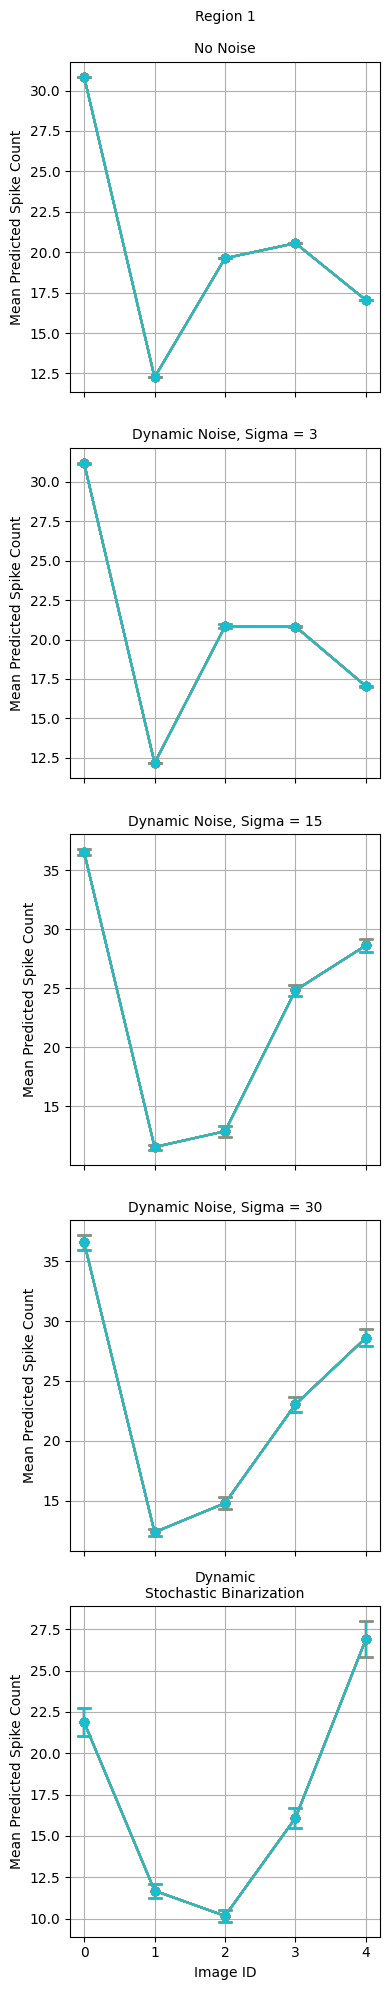

In [33]:
five_turning_curves(d5arrays_r1, dr1_titles)

#### mean var plots

In [25]:
def mean_var_scatter(mean_array, var_array, title):
    plt.figure(figsize = (6,4))
    cmap = plt.get_cmap('viridis')
    colors = cmap(np.linspace(0, 1, d3_mean.shape[1]))

    #range_neurons = d3_mean.shape[1]-1

    for neuron in range(mean_array.shape[1]): 
        plt.scatter(mean_array[:, neuron], 
                    var_array[:, neuron],  
                    marker = '^', color = colors[neuron])

    x = mean_array[:, :].flatten()
    y = var_array[:, :].flatten()

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    x_fit = np.linspace(np.min(x), np.max(x), 100)
    y_fit = intercept + slope * x_fit
    plt.plot(x_fit, y_fit, color='red', label='Regression line', linewidth=2)

    se_fit = std_err * np.sqrt(1/len(x) + (x_fit - np.mean(x))**2 / np.sum((x - np.mean(x))**2))
    plt.fill_between(x_fit, y_fit - 1.96 * se_fit, y_fit + 1.96 * se_fit, color='gray', alpha=0.3, label='95% CI')

    plt.text(np.min(x), np.max(y), f"Slope: {slope:.3f}\n95% CI: [{slope - 1.96*std_err:.3f}, {slope + 1.96*std_err:.3f}]", fontsize=8, verticalalignment='top')

    plt.title(f'{title}')
    plt.grid(True)    
    plt.tight_layout()
    plt.xlabel('Mean Predicted Spike Count')
    plt.ylabel('Variance in Predicted Spike Count')
    plt.show()

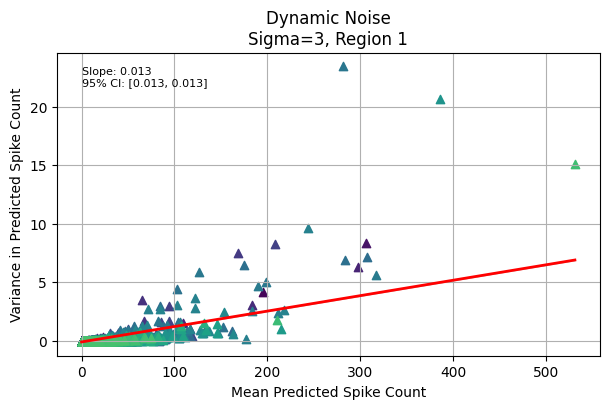

In [26]:
# test plot, region 1 dynamic noise
mean_var_scatter(d3_mean_r1, d3_var_r1, 'Dynamic Noise\nSigma=3, Region 1')

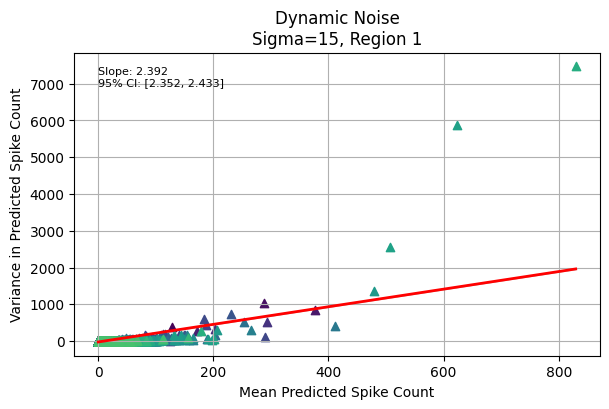

In [28]:
# test plot, region 1 dynamic noise
mean_var_scatter(d15_mean_r1, d15_var_r1, 'Dynamic Noise\nSigma=15, Region 1')

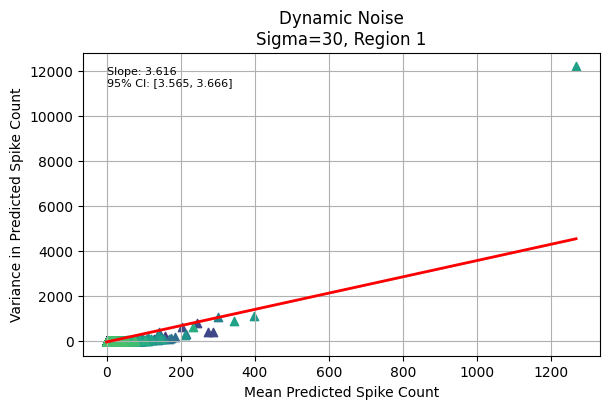

In [29]:
# test plot, region 1 dynamic noise
mean_var_scatter(d30_mean_r1, d30_var_r1, 'Dynamic Noise\nSigma=30, Region 1')

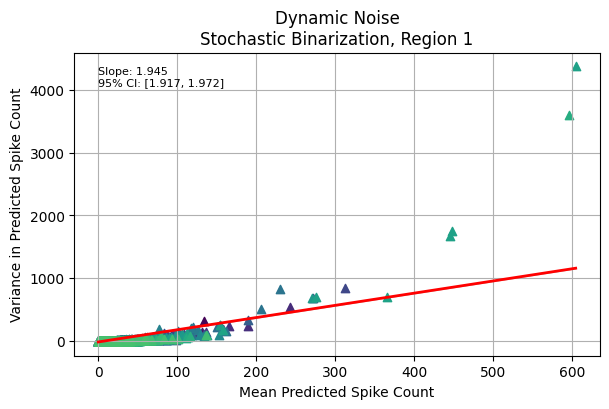

In [30]:
mean_var_scatter(dbin_mean_r1, dbin_var_r1, 'Dynamic Noise\nStochastic Binarization, Region 1')